In [1]:
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold

from sklearn.ensemble import HistGradientBoostingClassifier

import spacy

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/project data/Twitter_Analysis.csv', index_col=0)
#print(df.head())

In [4]:
df.head()

,majority_target,statement,BinaryNumTarget,tweet,followers_count,friends_count,favourites_count,statuses_count,listed_count,following,embeddings,BotScore,BotScoreBinary,cred,normalize_influence,mentions,quotes,replies,retweets,favourites,hashtags,URLs,unique_count,total_count,ORG_percentage,NORP_percentage,GPE_percentage,PERSON_percentage,MONEY_percentage,DATE_percentage,CARDINAL_percentage,PERCENT_percentage,ORDINAL_percentage,FAC_percentage,LAW_percentage,PRODUCT_percentage,EVENT_percentage,TIME_percentage,LOC_percentage,WORK_OF_ART_percentage,QUANTITY_percentage,LANGUAGE_percentage,Word count,Max word length,Min word length,Average word length,present_verbs,past_verbs,adjectives,adverbs,adpositions,pronouns,TOs,determiners,conjunctions,dots,exclamation,questions,ampersand,capitals,digits,long_word_freq,short_word_freq
0,True,End of eviction moratorium means millions of A...,1.0,@POTUS Biden Blunders - 6 Month Update\n\nInfl...,4262.0,3619.0,34945.0,16423.0,44.0,0.0,[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]],0.03,0.0,0.540794,0.104602,1.0,1.0,1.0,3.0,10.0,0.0,1.0,5,6,0.333333,0.166667,0.166667,0.166667,0.166667,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,42,14,1,5.476190,1,1,1,0,4,1,0,0,0,5,0,1,0,33,3,5,19
1,True,End of eviction moratorium means millions of A...,1.0,@S0SickRick @Stairmaster_ @6d6f636869 Not as m...,1393.0,1621.0,31436.0,37184.0,64.0,0.0,[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]],0.03,0.0,0.462177,0.094436,3.0,0.0,0.0,0.0,1.0,0.0,1.0,2,4,0.000000,0.250000,0.000000,0.750000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,51,15,1,4.627451,7,2,2,0,5,8,2,0,2,1,0,0,0,14,0,2,34
2,True,End of eviction moratorium means millions of A...,1.0,THE SUPREME COURT is siding with super rich pr...,9.0,84.0,219.0,1184.0,0.0,0.0,[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]],0.03,0.0,0.096774,0.039846,0.0,2.0,5.0,0.0,0.0,0.0,1.0,1,1,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,26,16,1,6.038462,0,0,7,3,1,0,1,0,1,0,0,0,0,3,0,4,10
3,True,End of eviction moratorium means millions of A...,1.0,@POTUS Biden Blunders\n\nBroken campaign promi...,4262.0,3619.0,34945.0,16423.0,44.0,0.0,[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]],0.03,0.0,0.540794,0.104602,1.0,0.0,0.0,0.0,0.0,0.0,1.0,4,6,0.000000,0.333333,0.000000,0.166667,0.166667,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49,10,2,4.653061,4,6,3,2,7,1,1,0,1,3,0,0,1,6,8,1,30
4,True,End of eviction moratorium means millions of A...,1.0,@OhComfy I agree. The confluence of events rig...,70.0,166.0,15282.0,2194.0,0.0,0.0,[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]],0.03,0.0,0.296610,0.061135,1.0,0.0,0.0,0.0,1.0,0.0,1.0,3,3,0.333333,0.000000,0.333333,0.000000,0.333333,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33,12,1,5.121212,2,2,2,3,2,2,0,0,1,3,0,1,0,11,3,2,19


In [5]:
# Drop the undocumented and non-reproducible columns
COLS_TO_DROP = [
    "embeddings",          # undocumented, not in official dataset
    "tweet",               # raw text, not a feature
    "statement",           # raw text, not a feature  
    "majority_target",     # string version of label
    "BinaryNumTarget",     # this is your y, not a feature
]

# These are the contested columns — audit before deciding
CONTESTED = ["cred", "normalize_influence", "BotScoreBinary", "BotScore"]

X = df.drop(columns=COLS_TO_DROP)
y = df["BinaryNumTarget"].astype(int)

In [6]:
print('cred:')
print(df['cred'].describe())
print('\nfollowers/(followers+friends+1):')
print((df['followers_count'] / (df['followers_count'] + df['friends_count'] + 1)).describe())

cred:
count    134198.000000
mean          0.405852
std           0.239223
min           0.000000
25%           0.223684
50%           0.386691
75%           0.525020
max           1.000000
Name: cred, dtype: float64

followers/(followers+friends+1):
count    134198.000000
mean          0.403138
std           0.236903
min           0.000000
25%           0.222222
50%           0.385042
75%           0.522727
max           1.000000
dtype: float64


Text(0.5, 1.0, 'cred (blue) and recreation (orange)')

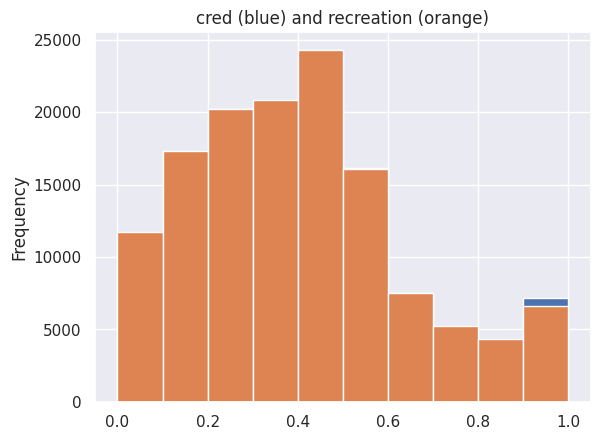

In [7]:
df['cred'].plot.hist()
(df['followers_count'] / (df['followers_count'] + df['friends_count'] + 1)).plot.hist()
plt.title('cred (blue) and recreation (orange)')

In [8]:
print('normalize_influence:')
print(df['normalize_influence'].describe())
print('\nlog(followers_count * retweets')
print(np.log1p(df['followers_count'] * df['retweets']).describe())

normalize_influence:
count    134198.000000
mean          0.077665
std           0.026184
min           0.000000
25%           0.061814
50%           0.079436
75%           0.095308
max           0.208606
Name: normalize_influence, dtype: float64

log(followers_count * retweets
count    134198.000000
mean          1.368236
std           3.424355
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          26.612075
dtype: float64


[]

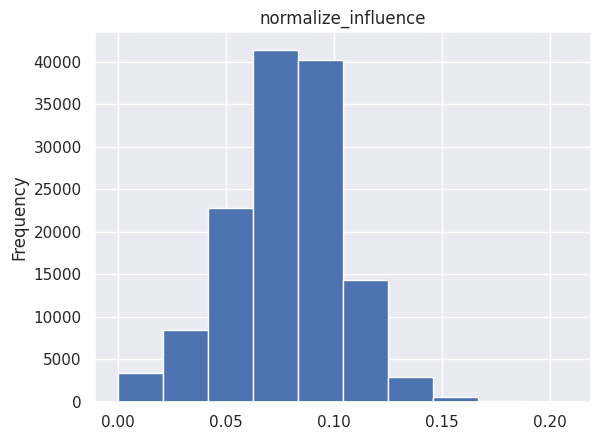

In [9]:
df['normalize_influence'].plot.hist()
plt.title('normalize_influence')
plt.plot()
#(np.log1p(df['followers_count'] * df['retweets'])).plot.hist()

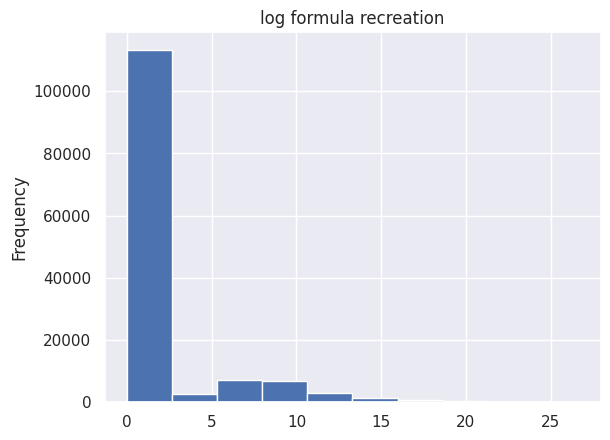

In [10]:
(np.log1p(df['followers_count'] * df['retweets'])).plot.hist()
plt.title('log formula recreation')
plt.show()

In [11]:
import numpy as np

# The actual target stats for reference
# mean=0.077, std=0.026, min=0, max=0.209, 75th pct=0.095

# --- Candidate 1: listed_count-based (strongest Twitter influence proxy) ---
# listed_count = number of public lists a user is on — curated by other users,
# it's the cleanest single influence signal Twitter exposes
c1 = df['listed_count'] / (df['listed_count'] + df['followers_count'] + 1)

# --- Candidate 2: log-follower normalized by dataset max ---
# "normalize" almost always means divide by dataset-level max in CIC papers
log_followers = np.log1p(df['followers_count'])
c2 = log_followers / log_followers.max()

# --- Candidate 3: composite log score normalized by dataset max ---
# followers + listed is the standard Cha et al. influence combination
log_composite = np.log1p(df['followers_count'] + df['listed_count'])
c3 = log_composite / log_composite.max()

# --- Candidate 4: engagement rate over account history ---
# retweets + favourites (per-tweet) over total statuses
c4 = (df['retweets'] + df['favourites']) / (df['statuses_count'] + 1)

# --- Candidate 5: listed_count normalized by dataset max (pure) ---
c5 = np.log1p(df['listed_count']) / np.log1p(df['listed_count'].max())

candidates = [("listed/(listed+followers+1)", c1),
                ("log(followers)/max", c2),
                ("log(followers+listed)/max", c3),
                ("(rt+fav)/statuses", c4),
                ("log(listed)/max", c5)]

for name, c in candidates:
    print(f"{name:35s}  mean={c.mean():.3f}  std={c.std():.3f}  "
          f"max={c.max():.3f}  75pct={c.quantile(.75):.3f}")

listed/(listed+followers+1)          mean=0.016  std=0.038  max=0.875  75pct=0.018
log(followers)/max                   mean=0.310  std=0.126  max=1.000  75pct=0.394
log(followers+listed)/max            mean=0.311  std=0.125  max=1.000  75pct=0.395
(rt+fav)/statuses                    mean=0.005  std=0.232  max=65.296  75pct=0.000
log(listed)/max                      mean=0.129  std=0.144  max=1.000  75pct=0.202


In [12]:
from scipy.stats import pearsonr

for name, c in candidates:
    r, _ = pearsonr(c.fillna(0), df['normalize_influence'])
    print(f"{name:35s}  r={r:.4f}")

listed/(listed+followers+1)          r=-0.0807
log(followers)/max                   r=0.9945
log(followers+listed)/max            r=0.9944
(rt+fav)/statuses                    r=0.0167
log(listed)/max                      r=0.7073


In [13]:
X.columns

Index(['followers_count', 'friends_count', 'favourites_count',
       'statuses_count', 'listed_count', 'following', 'BotScore',
       'BotScoreBinary', 'cred', 'normalize_influence', 'mentions', 'quotes',
       'replies', 'retweets', 'favourites', 'hashtags', 'URLs', 'unique_count',
       'total_count', 'ORG_percentage', 'NORP_percentage', 'GPE_percentage',
       'PERSON_percentage', 'MONEY_percentage', 'DATE_percentage',
       'CARDINAL_percentage', 'PERCENT_percentage', 'ORDINAL_percentage',
       'FAC_percentage', 'LAW_percentage', 'PRODUCT_percentage',
       'EVENT_percentage', 'TIME_percentage', 'LOC_percentage',
       'WORK_OF_ART_percentage', 'QUANTITY_percentage', 'LANGUAGE_percentage',
       'Word count', 'Max word length', 'Min word length',
       'Average word length', 'present_verbs', 'past_verbs', 'adjectives',
       'adverbs', 'adpositions', 'pronouns', 'TOs', 'determiners',
       'conjunctions', 'dots', 'exclamation', 'questions', 'ampersand',
       'capita

In [14]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = HistGradientBoostingClassifier(random_state=42)
model.fit(X_tr, y_tr)

perm = permutation_importance(
    model, X_val, y_val,
    n_repeats=10, scoring="roc_auc",
    random_state=42, n_jobs=-1
)

importance = pd.Series(perm.importances_mean, index=X.columns)

# Split the verdict
contested_imp  = importance[CONTESTED].sort_values(ascending=False)
remaining_imp  = importance.drop(CONTESTED).nlargest(15)

print("=== Contested features (unscrapeable) ===")
print(contested_imp.round(4))
print("\n=== Top 15 reproducible features ===")
print(remaining_imp.round(4))

=== Contested features (unscrapeable) ===
normalize_influence    0.0029
cred                   0.0028
BotScore               0.0001
BotScoreBinary         0.0000
dtype: float64

=== Top 15 reproducible features ===
listed_count           0.0287
PERSON_percentage      0.0224
Word count             0.0170
URLs                   0.0161
past_verbs             0.0149
CARDINAL_percentage    0.0127
digits                 0.0126
Average word length    0.0110
adjectives             0.0104
favourites_count       0.0096
MONEY_percentage       0.0094
capitals               0.0094
NORP_percentage        0.0086
PERCENT_percentage     0.0086
adpositions            0.0081
dtype: float64


## Training the Model

In [14]:
# Drop the undocumented and non-reproducible columns
COLS_TO_DROP = [
    "embeddings",          # undocumented, not in official dataset
    "tweet",               # raw text, not a feature
    "statement",           # raw text, not a feature  
    "majority_target",     # string version of label
    "BinaryNumTarget",     # this is your y, not a feature
    'followers_count', 'friends_count', 'favourites_count', # (User favourites)
    'statuses_count', 'listed_count', 'following', 
    'BotScore', 'BotScoreBinary', 'cred', 'normalize_influence',
    'retweets',
    'quotes' 
]

# These are the contested columns — audit before deciding
#CONTESTED = ["cred", "normalize_influence", "BotScoreBinary", "BotScore"]

X = df.drop(columns=COLS_TO_DROP)
y = df["BinaryNumTarget"].astype(int)

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [15]:
X_tr.columns

Index(['mentions', 'replies', 'favourites', 'hashtags', 'URLs', 'unique_count',
       'total_count', 'ORG_percentage', 'NORP_percentage', 'GPE_percentage',
       'PERSON_percentage', 'MONEY_percentage', 'DATE_percentage',
       'CARDINAL_percentage', 'PERCENT_percentage', 'ORDINAL_percentage',
       'FAC_percentage', 'LAW_percentage', 'PRODUCT_percentage',
       'EVENT_percentage', 'TIME_percentage', 'LOC_percentage',
       'WORK_OF_ART_percentage', 'QUANTITY_percentage', 'LANGUAGE_percentage',
       'Word count', 'Max word length', 'Min word length',
       'Average word length', 'present_verbs', 'past_verbs', 'adjectives',
       'adverbs', 'adpositions', 'pronouns', 'TOs', 'determiners',
       'conjunctions', 'dots', 'exclamation', 'questions', 'ampersand',
       'capitals', 'digits', 'long_word_freq', 'short_word_freq'],
      dtype='object')

In [17]:
from sklearn.metrics import make_scorer, f1_score

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
model = HistGradientBoostingClassifier(random_state=42)


param_grid = {
    "learning_rate":     [0.05, 0.1],       # 0.01 too slow, 1.0 broken
    "max_iter":          [200, 400, 600],    # 100 was still improving
    "max_leaf_nodes":    [255, 511],    # 127 was still improving
    "min_samples_leaf":  [10, 20],           # regularization — not yet searched
    "l2_regularization": [0.0, 0.05],        # regularization — not yet searched
}

search = GridSearchCV(
    model,
    param_grid=param_grid,
    scoring='f1',
    refit=False,
    cv=cv,
    verbose=2,
)

In [18]:
search.fit(X_tr, y_tr)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
[CV] END l2_regularization=0.0, learning_rate=0.05, max_iter=200, max_leaf_nodes=255, min_samples_leaf=10; total time=  16.6s
[CV] END l2_regularization=0.0, learning_rate=0.05, max_iter=200, max_leaf_nodes=255, min_samples_leaf=10; total time=  14.0s
[CV] END l2_regularization=0.0, learning_rate=0.05, max_iter=200, max_leaf_nodes=255, min_samples_leaf=10; total time=  16.7s
[CV] END l2_regularization=0.0, learning_rate=0.05, max_iter=200, max_leaf_nodes=255, min_samples_leaf=20; total time=  16.0s
[CV] END l2_regularization=0.0, learning_rate=0.05, max_iter=200, max_leaf_nodes=255, min_samples_leaf=20; total time=  16.9s
[CV] END l2_regularization=0.0, learning_rate=0.05, max_iter=200, max_leaf_nodes=255, min_samples_leaf=20; total time=  17.2s
[CV] END l2_regularization=0.0, learning_rate=0.05, max_iter=200, max_leaf_nodes=511, min_samples_leaf=10; total time=  23.4s
[CV] END l2_regularization=0.0, learning_rate=0.05, max_

GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
             estimator=HistGradientBoostingClassifier(random_state=42),
             param_grid={'l2_regularization': [0.0, 0.05],
                         'learning_rate': [0.05, 0.1],
                         'max_iter': [200, 400, 600],
                         'max_leaf_nodes': [255, 511],
                         'min_samples_leaf': [10, 20]},
             refit=False, scoring='f1', verbose=2)

In [19]:
search.best_params_

{'l2_regularization': 0.05,
 'learning_rate': 0.05,
 'max_iter': 400,
 'max_leaf_nodes': 255,
 'min_samples_leaf': 20}

In [20]:
results = pd.DataFrame(search.cv_results_)
results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_l2_regularization,param_learning_rate,param_max_iter,param_max_leaf_nodes,param_min_samples_leaf,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,14.231507,1.175250,1.555091,0.063103,0.0,0.05,200,255,10,"{'l2_regularization': 0.0, 'learning_rate': 0....",0.700757,0.701719,0.701431,0.701302,0.000403,14
1,14.872081,0.398051,1.868255,0.115369,0.0,0.05,200,255,20,"{'l2_regularization': 0.0, 'learning_rate': 0....",0.700322,0.703900,0.700341,0.701521,0.001682,11
2,20.836353,1.376601,2.063536,0.090306,0.0,0.05,200,511,10,"{'l2_regularization': 0.0, 'learning_rate': 0....",0.698439,0.703813,0.699245,0.700499,0.002366,19
3,18.192900,1.329092,1.879666,0.240303,0.0,0.05,200,511,20,"{'l2_regularization': 0.0, 'learning_rate': 0....",0.700390,0.701395,0.697859,0.699881,0.001488,22
4,14.168381,1.495030,1.590408,0.111550,0.0,0.05,400,255,10,"{'l2_regularization': 0.0, 'learning_rate': 0....",0.701218,0.701719,0.701431,0.701456,0.000205,12


In [28]:
print(results)

    mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0       12.367277      0.281310         3.712276        0.223672   
1       12.391017      0.065572         2.784085        0.035718   
2       17.748708      0.488153         3.415620        0.234634   
3       17.056586      0.493936         3.849196        0.261822   
4       26.387608      0.444011         5.275572        0.726635   
5       26.720177      0.130828         5.945848        0.776098   
6       17.960781      3.583818         4.595438        0.224267   
7       19.159843      1.800932         5.358960        0.284644   
8       23.234974      2.770829         5.583176        0.405375   
9       24.037453      0.973524         5.917019        0.413978   
10      26.434528      0.388347         5.786720        0.520202   
11      29.437570      1.274374         5.924080        0.508975   
12      17.905207      3.592243         4.406463        0.696219   
13      18.546167      1.993300         5.151653

In [31]:
results.nsmallest(1, 'rank_test_f1_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_l2_regularization,param_learning_rate,param_max_iter,param_max_leaf_nodes,param_min_samples_leaf,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,mean_test_accuracy,std_test_accuracy,rank_test_accuracy,split0_test_f1_score,split1_test_f1_score,split2_test_f1_score,mean_test_f1_score,std_test_f1_score,rank_test_f1_score,split0_test_roc_auc,split1_test_roc_auc,split2_test_roc_auc,mean_test_roc_auc,std_test_roc_auc,rank_test_roc_auc
47,25.452428,2.455332,4.901441,0.11881,0.1,0.05,400,511,20,"{'l2_regularization': 0.1, 'learning_rate': 0....",0.710781,0.713966,0.715391,0.71338,0.001928,1,0.71374,0.718668,0.718794,0.717067,0.002353,1,0.787718,0.791831,0.794858,0.791469,0.002926,1


In [32]:
results.nsmallest(1, 'rank_test_accuracy')


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_l2_regularization,param_learning_rate,param_max_iter,param_max_leaf_nodes,param_min_samples_leaf,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,mean_test_accuracy,std_test_accuracy,rank_test_accuracy,split0_test_f1_score,split1_test_f1_score,split2_test_f1_score,mean_test_f1_score,std_test_f1_score,rank_test_f1_score,split0_test_roc_auc,split1_test_roc_auc,split2_test_roc_auc,mean_test_roc_auc,std_test_roc_auc,rank_test_roc_auc
47,25.452428,2.455332,4.901441,0.11881,0.1,0.05,400,511,20,"{'l2_regularization': 0.1, 'learning_rate': 0....",0.710781,0.713966,0.715391,0.71338,0.001928,1,0.71374,0.718668,0.718794,0.717067,0.002353,1,0.787718,0.791831,0.794858,0.791469,0.002926,1


In [33]:
results.nsmallest(1, 'rank_test_roc_auc')


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_l2_regularization,param_learning_rate,param_max_iter,param_max_leaf_nodes,param_min_samples_leaf,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,mean_test_accuracy,std_test_accuracy,rank_test_accuracy,split0_test_f1_score,split1_test_f1_score,split2_test_f1_score,mean_test_f1_score,std_test_f1_score,rank_test_f1_score,split0_test_roc_auc,split1_test_roc_auc,split2_test_roc_auc,mean_test_roc_auc,std_test_roc_auc,rank_test_roc_auc
47,25.452428,2.455332,4.901441,0.11881,0.1,0.05,400,511,20,"{'l2_regularization': 0.1, 'learning_rate': 0....",0.710781,0.713966,0.715391,0.71338,0.001928,1,0.71374,0.718668,0.718794,0.717067,0.002353,1,0.787718,0.791831,0.794858,0.791469,0.002926,1


In [22]:
model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=400,
    l2_regularization=0.05,
    max_leaf_nodes=255,
    min_samples_leaf=20,
    random_state=42
)

In [23]:
model.fit(X_tr, y_tr)

HistGradientBoostingClassifier(l2_regularization=0.05, learning_rate=0.05,
                               max_iter=400, max_leaf_nodes=255,
                               random_state=42)

In [26]:
import joblib
joblib.dump(model, '/content/drive/My Drive/Colab Notebooks/social_model.joblib', compress=3)

['/content/drive/My Drive/Colab Notebooks/social_model.joblib']

# Post Training

In [ ]:
# get results of model on validation set
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, f1_score, precision_score, recall_score
y_pred = model.predict(X_val)
print("Accuracy:", accuracy_score(y_val, y_pred))
print("F1 Score:", f1_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred))
print("Recall:", recall_score(y_val, y_pred))
print(classification_report(y_val, y_pred))
print("ROC AUC:", roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))

Accuracy: 0.72075260804769
F1 Score: 0.7247217835237081
Precision: 0.7340227661632319
Recall: 0.7156535615842159
              precision    recall  f1-score   support

           0       0.71      0.73      0.72     13054
           1       0.73      0.72      0.72     13786

    accuracy                           0.72     26840
   macro avg       0.72      0.72      0.72     26840
weighted avg       0.72      0.72      0.72     26840

ROC AUC: 0.8026221959955155


In [24]:
# get results of model on validation set
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, f1_score, precision_score, recall_score
y_pred = model.predict(X_val)
print("Accuracy:", accuracy_score(y_val, y_pred))
print("F1 Score:", f1_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred))
print("Recall:", recall_score(y_val, y_pred))
print(classification_report(y_val, y_pred))
print("ROC AUC:", roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))

Accuracy: 0.7040983606557377
F1 Score: 0.7100824998174783
Precision: 0.7147266313932981
Recall: 0.705498331640795
              precision    recall  f1-score   support

           0       0.69      0.70      0.70     13054
           1       0.71      0.71      0.71     13786

    accuracy                           0.70     26840
   macro avg       0.70      0.70      0.70     26840
weighted avg       0.70      0.70      0.70     26840

ROC AUC: 0.7799317284221813


In [24]:
# get results of model on validation set
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, f1_score, precision_score, recall_score
y_pred = model.predict(X_val)
print("Accuracy:", accuracy_score(y_val, y_pred))
print("F1 Score:", f1_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred))
print("Recall:", recall_score(y_val, y_pred))
print(classification_report(y_val, y_pred))
print("ROC AUC:", roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))

Accuracy: 0.7023472429210134
F1 Score: 0.7085901878533649
Precision: 0.7126715092816788
Recall: 0.7045553460031917
              precision    recall  f1-score   support

           0       0.69      0.70      0.70     13054
           1       0.71      0.70      0.71     13786

    accuracy                           0.70     26840
   macro avg       0.70      0.70      0.70     26840
weighted avg       0.70      0.70      0.70     26840

ROC AUC: 0.7788481134430469
